In [71]:
import numpy as np
import matplotlib.pyplot as plt

import cirq

import stim
from stimcirq import cirq_circuit_to_stim_circuit

import pymatching

from encoded.utils import cirq_pauli_string_to_stim
from encoded.expanded_repetition_code import (
    x_bar,
    z_bar,
    stabilizer_generators,
    encoding_expanded_repetition
)

## Test a physical qubit

In [72]:

def physical_qubit_memory_circuit(p_depol: float):
    circuit = stim.Circuit()
    circuit.append("DEPOLARIZE1", 0, arg=p_depol)
    circuit.append("M", 0)
    return circuit

In [73]:
error_rates = np.linspace(1e-4, 0.1, num=10)
num_shots = 10_000
physical_err_rates = np.zeros(error_rates.size)
for i, error_rate in enumerate(error_rates):
    ckt = physical_qubit_memory_circuit(error_rate)
    sampler = ckt.compile_sampler()
    result = sampler.sample(num_shots)
    physical_err_rates[i] = np.sum(result) / num_shots

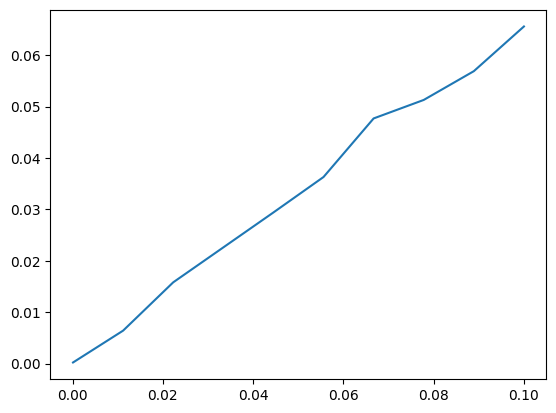

In [74]:
fig, ax = plt.subplots()
ax.plot(error_rates, physical_err_rates)

## Test a logical qubit

In [75]:
qs = cirq.LineQubit.range(4)
generators = stabilizer_generators
for generator in generators:
    print(generator)

Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))


In [76]:
def expanded_repetition_circuit_memory_z(p_depol: float, error_ratio: float):
    """Circuit for a memory experiment with the expanded repetition code.
    
    Arguments:
    p_depol: Probability of a depolarizing errors on the original three qubits.
    error_ratio: Ratio of error probability of the fourth qubit to the other three (p_depol).
    
    Returns:
    A memory experiment circuit."""

    generator_ckt = stim.Circuit()
    for generator in generators:
        generator_ckt.append("MPP", cirq_pauli_string_to_stim(generator, qs))
    
    noise_ckt = stim.Circuit()
    noise_ckt.append("DEPOLARIZE1", [0, 1, 2], arg=p_depol)
    noise_ckt.append("DEPOLARIZE1", 3, arg=error_ratio * p_depol)

    circuit = stim.Circuit()
    # Prepare the logical |0> state.
    encoding_cirq, _ = encoding_expanded_repetition('0')
    circuit += cirq_circuit_to_stim_circuit(encoding_cirq)
    # Do transversal initialization.
    circuit += generator_ckt
    for i in range(3):
        circuit.append_from_stim_program_text(f"DETECTOR rec[{-i - 1}]")
    circuit.append("TICK")
    # Subject the qubits to noise, then do a round of syndrome measurement.
    circuit += noise_ckt
    circuit += generator_ckt
    for i in range(3):
        circuit.append_from_stim_program_text(f"DETECTOR rec[{-i - 1}] rec[{-i - 1 - 3}]")
    # Measure logical Z as the observable for the experiment.
    circuit.append("MPP", cirq_pauli_string_to_stim(z_bar, qs))
    circuit.append_from_stim_program_text("OBSERVABLE_INCLUDE(0) rec[-1]")
    return circuit

In [77]:
circuit = expanded_repetition_circuit_memory_z(0.1, 1e-2)
print(circuit)

I 0 1 2
TICK
H 0 1 2
TICK
CX 0 3
TICK
CX 1 3
H 0
TICK
CX 2 3
H 1
TICK
H 2 3
TICK
MPP Z0*Z1 Z1*Z2 X0*X1*X2*X3
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
TICK
DEPOLARIZE1(0.1) 0 1 2
DEPOLARIZE1(0.001) 3
MPP Z0*Z1 Z1*Z2 X0*X1*X2*X3
DETECTOR rec[-1] rec[-4]
DETECTOR rec[-2] rec[-5]
DETECTOR rec[-3] rec[-6]
MPP Z0*Z3
OBSERVABLE_INCLUDE(0) rec[-1]


In [78]:
sampler = circuit.compile_detector_sampler()
result = sampler.sample(10)
print(result)

[[False False False  True False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False  True False False]
 [False False False False False False]]


In [79]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

In [80]:
print(count_logical_errors(circuit, num_shots))

142


In [83]:
lers = np.zeros(error_rates.shape)
for i, error_rate in enumerate(error_rates):
    circuit = expanded_repetition_circuit_memory_z(error_rate, 0.75)
    num_errs = count_logical_errors(circuit, num_shots)
    print(f"Got {num_errs} logical errors.")
    lers[i] = float(num_errs) / num_shots

Got 1 logical errors.
Got 58 logical errors.
Got 138 logical errors.
Got 186 logical errors.
Got 231 logical errors.
Got 307 logical errors.
Got 380 logical errors.
Got 406 logical errors.
Got 536 logical errors.
Got 608 logical errors.


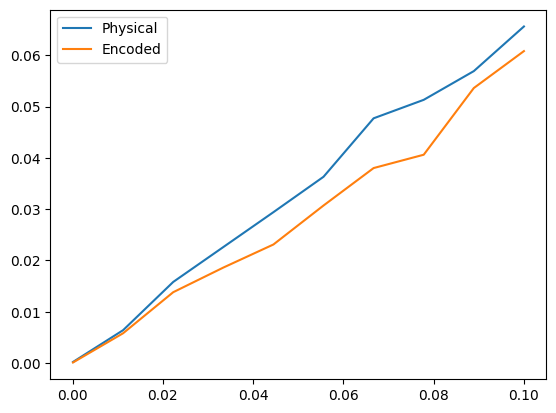

In [84]:
fig, ax = plt.subplots()
ax.plot(error_rates, physical_err_rates, label="Physical")
ax.plot(error_rates, lers, label="Encoded")
ax.legend()